# Evaluation Metrics
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Accuracy, Precision, Recall, F1, confusion matrix, and ROC curve, demonstrated on a deliberately imbalanced dataset.

Main goals:

- Compute and interpret a confusion matrix.
- Compute Accuracy, Precision, Recall, and F1 from the same predictions.
- Plot an ROC curve and compute AUC.
- Show how each metric behaves differently on imbalanced data.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score)

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Imbalanced Dataset

In [2]:
X, y = make_classification(n_samples=2000, n_features=8, n_informative=5,
                           weights=[0.92, 0.08], random_state=42)

print('Class counts:', np.bincount(y))
print(f'Minority class rate: {y.mean()*100:.1f}%')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

Class counts: [1829  171]
Minority class rate: 8.6%


## Confusion Matrix

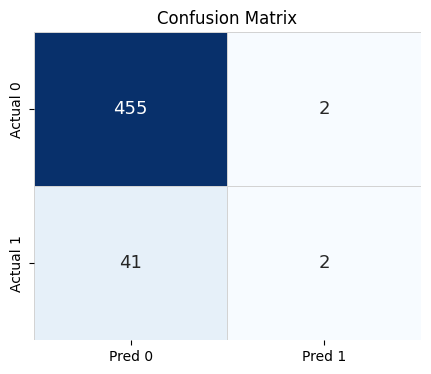

TN=455  FP=2  FN=41  TP=2


In [3]:
model = LogisticRegression().fit(X_train_s, y_train)
preds = model.predict(X_test_s)
probs = model.predict_proba(X_test_s)[:, 1]

cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'],
            linewidths=0.5, linecolor='lightgray', cbar=False, annot_kws={'size': 13})
ax.set_title('Confusion Matrix')
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

## Accuracy, Precision, Recall, F1

In [4]:
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds)
rec = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1:        {f1:.4f}')

always_zero_acc = accuracy_score(y_test, np.zeros_like(y_test))
print(f'\nAccuracy of always predicting 0: {always_zero_acc:.4f}')

Accuracy:  0.9140
Precision: 0.5000
Recall:    0.0465
F1:        0.0851

Accuracy of always predicting 0: 0.9140


**Observation:**
Always predicting the majority class scores nearly as high on accuracy as the trained model. Precision and Recall expose what accuracy hides — they only look at how the model handles the positive class.

In [5]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.95       457
           1       0.50      0.05      0.09        43

    accuracy                           0.91       500
   macro avg       0.71      0.52      0.52       500
weighted avg       0.88      0.91      0.88       500



## ROC Curve

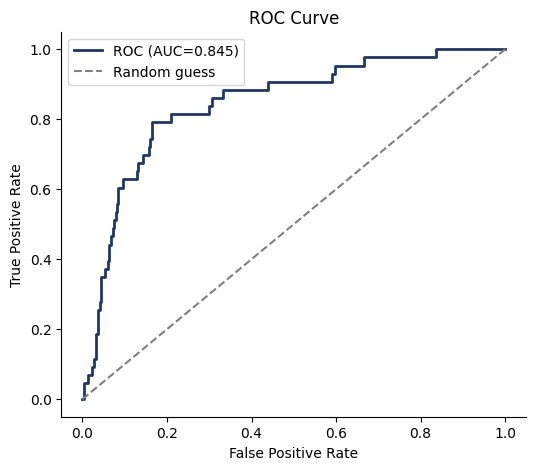

AUC: 0.8451


In [6]:
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#1F3864', lw=2, label=f'ROC (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

print(f'AUC: {auc:.4f}')

**Observation:**
AUC summarises performance across every possible threshold, not just the default 0.5 cutoff used for Precision/Recall above. A model with AUC well above 0.5 is ranking positives above negatives more often than chance, regardless of where the threshold is set.

## Threshold Effect on Precision and Recall

In [7]:
thresholds_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]

print(f'{"threshold":>10s}{"precision":>12s}{"recall":>10s}{"f1":>8s}')
for t in thresholds_to_test:
    preds_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_t, zero_division=0)
    r = recall_score(y_test, preds_t, zero_division=0)
    f = f1_score(y_test, preds_t, zero_division=0)
    print(f'{t:10.1f}{p:12.3f}{r:10.3f}{f:8.3f}')

 threshold   precision    recall      f1
       0.1       0.255     0.814   0.389
       0.3       0.393     0.256   0.310
       0.5       0.500     0.047   0.085
       0.7       0.000     0.000   0.000
       0.9       0.000     0.000   0.000


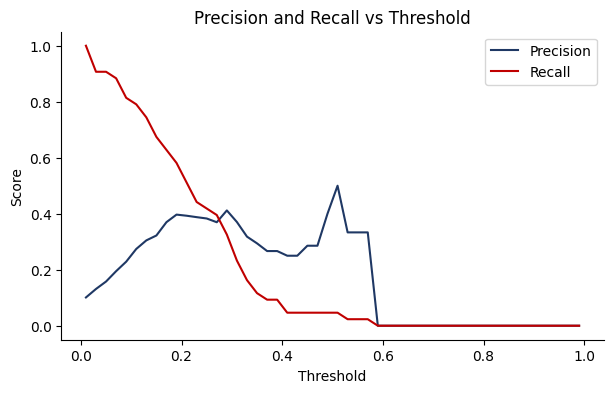

In [8]:
precisions, recalls = [], []
thresh_range = np.linspace(0.01, 0.99, 50)
for t in thresh_range:
    preds_t = (probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds_t, zero_division=0))
    recalls.append(recall_score(y_test, preds_t, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresh_range, precisions, color='#1F3864', label='Precision')
ax.plot(thresh_range, recalls, color='#C00000', label='Recall')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall vs Threshold')
ax.legend()
plt.show()

**Observation:**
Raising the threshold pushes Precision up and Recall down — the two move in opposite directions. The 0.5 default is not special, the right threshold depends on whether false positives or false negatives matter more for the specific problem.